# NIFTY IV Surface Reconstruction

### Finance Club IIT Roorkee Open Project 2026

This project aims to reconstruct missing implied volatility (IV) values in a partially observed NIFTY options dataset.

Final methodology:

- Log-Moneyness Transformation
- PCHIP Interpolation
- CubicSpline Interpolation
- 50/50 Ensemble

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.interpolate import (PchipInterpolator,CubicSpline)

In [3]:
df = pd.read_csv("../data/dataset.csv")

df.head()

,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,...,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,...,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [4]:
missing = df.isna().sum()

missing = missing[missing > 0]

print("Total Missing Values:",missing.sum())

missing.sort_values(ascending=False).head(10)

Total Missing Values: 5460


NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2626200CE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2624000PE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
dtype: int64

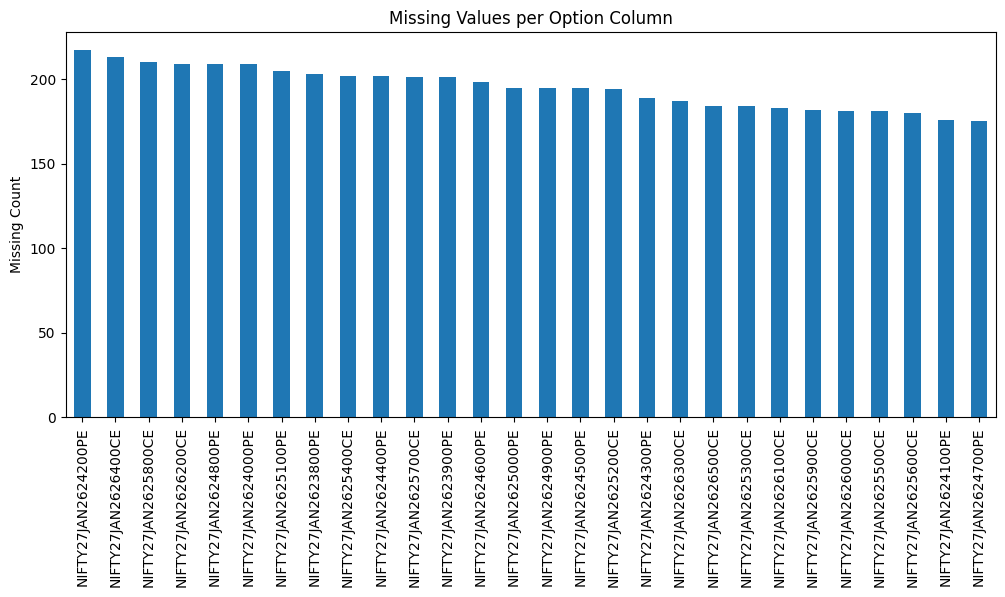

In [5]:
plt.figure(figsize=(12,5))

missing.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values per Option Column")

plt.ylabel("Missing Count")

plt.show()

In [6]:
option_cols = [
    c for c in df.columns
    if c not in [
        "datetime",
        "underlying_price"
    ]
]


def extract_strike(col):

    digits = ''.join(
        ch for ch in col
        if ch.isdigit()
        )

    return int(digits[-5:])


strikes = np.array([
    extract_strike(col)
    for col in option_cols
])

print("Number of strikes:",len(strikes))

print(np.sort(strikes))

Number of strikes: 28
[23800 23900 24000 24100 24200 24300 24400 24500 24600 24700 24800 24900
 25000 25100 25200 25300 25400 25500 25600 25700 25800 25900 26000 26100
 26200 26300 26400 26500]


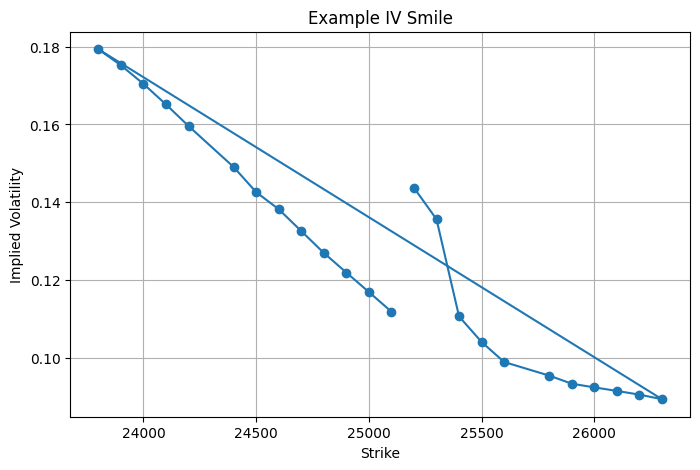

In [7]:
row = 100

ivs = (
    df.loc[row, option_cols]
    .values
    .astype(float)
)

mask = ~np.isnan(ivs)

plt.figure(figsize=(8,5))

plt.plot(strikes[mask],ivs[mask],marker="o")

plt.title("Example IV Smile")

plt.xlabel("Strike")

plt.ylabel("Implied Volatility")

plt.grid(True)

plt.show()

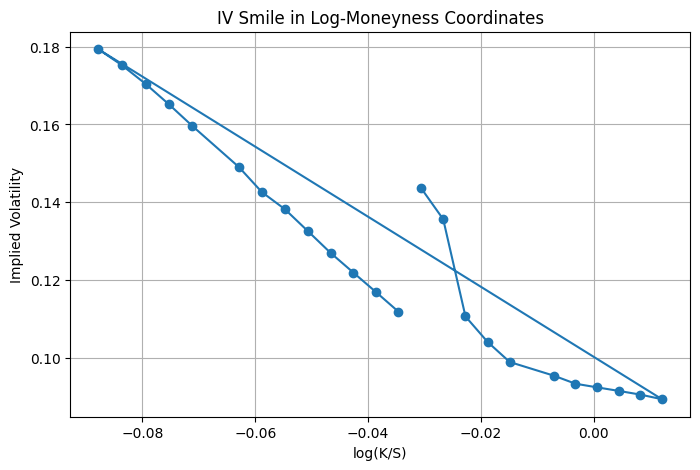

In [9]:
spot = float(df.loc[row,"underlying_price"])

log_m = np.log(strikes / spot)

plt.figure(figsize=(8,5))

plt.plot(log_m[mask],ivs[mask],marker="o")

plt.title("IV Smile in Log-Moneyness Coordinates")

plt.xlabel( "log(K/S)")

plt.ylabel("Implied Volatility")

plt.grid(True)

plt.show()

In [10]:
def fill_missing_iv(df):

    df = df.copy()

    option_cols = [
        c for c in df.columns
        if c not in [
            "datetime",
            "underlying_price"
        ]
    ]

    strikes = np.array([
        extract_strike(c)
        for c in option_cols
    ])

    order = np.argsort(
        strikes
    )

    strikes = strikes[order]

    option_cols = [
        option_cols[i]
        for i in order
    ]

    for row_idx in range(len(df)):

        spot = float(
            df.loc[
                row_idx,
                "underlying_price"
            ]
        )

        row = (
            df.loc[
                row_idx,
                option_cols
            ]
            .values
            .astype(float)
        )

        missing = np.isnan(row)

        if not missing.any():
            continue

        observed = ~missing

        if observed.sum() < 4:
            continue

        x_obs = np.log(
            strikes[observed]
            / spot
        )

        y_obs = row[observed]

        x_target = np.log(
            strikes[missing]
            / spot
        )

        pchip = PchipInterpolator(
            x_obs,
            y_obs
        )

        cubic = CubicSpline(
            x_obs,
            y_obs
        )

        pred = (
            0.5 * pchip(x_target)
            +
            0.5 * cubic(x_target)
        )

        row[missing] = pred

        df.loc[
            row_idx,
            option_cols
        ] = row

    return df

In [11]:
filled = fill_missing_iv(df)

filled.to_csv(
    "../output/filled_dataset.csv",
    index=False
)

print(
    "Filled dataset saved."
)

Filled dataset saved.


In [17]:
import pandas as pd

SEPARATOR = "||"

def generate_submission(
    original_path,
    filled_path,
    output_path
):

    original = pd.read_csv(original_path)
    filled = pd.read_csv(filled_path)

    feature_cols = [
        c for c in original.columns
        if c != "datetime"
    ]

    rows = []

    for col in feature_cols:

        missing_mask = original[col].isna()

        for idx in original.index[missing_mask]:

            dt = original.loc[idx, "datetime"]

            uid = f"{dt}{SEPARATOR}{col}"

            value = filled.loc[idx, col]

            rows.append({
                "id": uid,
                "value": value
            })

    submission = pd.DataFrame(rows)

    submission = (
        submission
        .sort_values("id")
        .reset_index(drop=True)
    )

    submission.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved -> {output_path}"
    )

In [18]:
generate_submission(
    "../data/dataset.csv",
    "../output/filled_dataset.csv",
    "../output/submission.csv"
)

Saved -> ../output/submission.csv


## Conclusion

The study evaluated multiple interpolation, machine learning, and volatility modeling approaches for IV surface reconstruction.

Key findings:

- Cross-sectional smile interpolation dominated time-series methods.
- CubicSpline captured smoothness effectively.
- PCHIP preserved local smile structure.
- A 50/50 ensemble provided robust performance.
- Log-moneyness offered a financially meaningful coordinate system.

Final model:

50% PCHIP + 50% CubicSpline on log(K/S).